# Multi-objective optimization

This notebook demonstrates how to perform **multi-objective** Bayesian optimization using the MO-SEGO (Multi-Objective Super Efficient Global Optimization) framework. Constrained and multi-fidelity optimization are also supported in the multi-objective framework.

In multi-objective optimization, we are interested in minimizing multiple $n$ objectives with respect to constraints $\boldsymbol{g}$ and $\boldsymbol{h}$ (if applicable).

$$
\min_{\boldsymbol{x} \in \Omega} \{ \boldsymbol{f}(\boldsymbol{x}) := [ f_1(\boldsymbol{x}), \; f_1(\boldsymbol{x}), \; \dots, \; f_n(\boldsymbol{x})]  \quad \text{s.t.} \quad \boldsymbol{g}(\boldsymbol{x}) \leq \boldsymbol{0} \; \text{and} \; \boldsymbol{h}(\boldsymbol{x}) = \boldsymbol{0}\}
$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim.core import (
    Driver,
    ObjectiveConfig,
    ConstraintConfig,
    DriverConfig,
    Problem,
)

from smt_optim.surrogate_models.smt import SmtAutoModel, SmtAutoModel

from smt_optim.acquisition_strategies.mosego import MOSEGO
from smt_optim.acquisition_functions.multi_obj import init_bi_obj_ei
from smt_optim.utils.multi_obj import get_pareto_front, get_pf_from_dataset

from smt_optim.benchmarks.registry import get_problem

from smt_optim.utils.multi_obj import PymooStateWrapper
from smt_optim.benchmarks.base import PymooWrapper
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

## Multi-objective optimization

The following example illustrates how to find the ZDT1's pareto front using the MO-SEGO framework. The code cell below imports the test problem using the `get_problem` method and plots both objective. The ZDT1 is defined as follow:

$$
\begin{aligned}
f_1(\boldsymbol x) & = x_1\\
f_2(\boldsymbol x) & = g(\boldsymbol x) h(f_1(\boldsymbol x), \; g(\boldsymbol x))
\end{aligned}
$$

where $d=2$ is the number of variable, $g(\boldsymbol x) = 1 + \frac{9}{d - 1}\sum_{i=2}^{d}x_i$, and $h(f_1, \; g) = 1 - \sqrt{f_1/g}$.



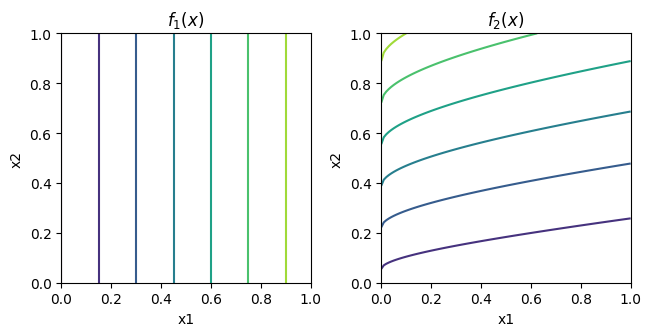

In [3]:
problem = get_problem("ZDT1")

problem.set_dim(2)

x1 = np.linspace(0, 1, 101)
x2 = np.linspace(0, 1, 101)

XX, YY = np.meshgrid(x1, x2)

data = np.vstack((XX.ravel(), YY.ravel())).T
f1 = np.empty(data.shape[0])
f2 = np.empty(data.shape[0])

for i in range(data.shape[0]):
    f1[i] = problem.f1(data[i, :])
    f2[i] = problem.f2(data[i, :])

F1 = f1.reshape(XX.shape)
F2 = f2.reshape(XX.shape)

fig, ax = plt.subplots(1, 2, layout="constrained")
ax[0].set_title(r"$f_1(x)$")
ax[0].contour(XX, YY, F1)
ax[1].set_title(r"$f_2(x)$")
ax[1].contour(XX, YY, F2)

for idx in range(2):
    ax[idx].set_xlabel("x1")
    ax[idx].set_ylabel("x2")
    ax[idx].set_aspect("equal")

plt.show()

### Starting the optimization

The code cell shows how to initialize both objective, the problem configuration, and the driver configuration. The driver is initialized with the `MOSEGO` acquisition strategy**, which is designed for multiple objective optimization. The **Expected Improvement (EI)** and **Probability of Improvement (PI)** analytical acquisition functions is used in this example.


In [4]:
# initialize the first objective configuration
obj1_config = ObjectiveConfig(
    [problem.f1],
    type="minimize",
    surrogate=SmtAutoModel,
)

# initialize the second objective configuration
obj2_config = ObjectiveConfig(
    [problem.f2],
    type="minimize",
    surrogate=SmtAutoModel,
)

# initialize the problem configuration
prob_definition = Problem(
    obj_configs=[obj1_config, obj2_config],
    design_space=problem.bounds,  # problem bounds
)

nt_init = 5

# initialize the driver
opt_config = DriverConfig(
    max_iter=30,
    nt_init=nt_init,
    verbose=True,
    scaling=True,
    seed=0,
)

driver = Driver(
    prob_definition,
    opt_config,
    MOSEGO,
    strategy_kwargs={"acq_func": init_bi_obj_ei, "n_start": 40, "sp_method": "SLSQP"},
)

# starts the optimization process
state = driver.optimize()

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             0              5            nan      0.000e+00            nan            nan            nan
             1              6            nan      0.000e+00              1          0.789          0.585
             2              7            nan      0.000e+00              1          0.971          0.269
             3              8            nan      0.000e+00              1          0.829          0.266
             4              9            nan      0.000e+00              1          0.793          0.242
             5             10            nan      0.000e+00              1          0.897          0.231
             6             11            nan      0.000e+00              1          0.890          0.265
             7             12            nan      0.000e+00              1          0.790          0.271
             8             13            nan      0.000

### Plotting the results

The code cell below extracts the pareto front from the final DOE using the `get_pf_from_dataset` method. The figure shows the final DOE, the initial DOE, the DOE samples forming the pareto front, and the true pareto front.


In [7]:
from smt_optim.utils.multi_obj import plot_pareto_front

# ======= Plot optimization and solution pareto front =======
# We pass the first nt_init points as the initial dataset
import copy
initial_dataset = copy.deepcopy(state.dataset)
initial_dataset.samples = initial_dataset.samples[:nt_init]
plot_pareto_front(initial_dataset, state.dataset, filename="zdt1_pareto_front.png")

import matplotlib.image as mpimg
img = mpimg.imread('zdt1_pareto_front.png')
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.show()


AttributeError: 'OptimizationDataset' object has no attribute 'samples'

## Constrained multi-objective optimization

The following example illustrates how to find the pareto front when subjected to constraints. The `get_problem` method is used to import the BNH test problem, which is defined as follow:

$$
\begin{aligned}
f_1(\boldsymbol x) & = 4x_1^2 + 4x_2^2\\
f_2(\boldsymbol x) & = (x_1 - 5)^2 + (x_2 - 5)^2\\
g_1(\boldsymbol x) & = (x_1 - 5)^2 + x_2^2 - 25\\
g_2(\boldsymbol x) & = -(x_1 - 8)^2 - (x_2^2+3)^2 + 7.7.
\end{aligned}
$$


In [5]:
problem = get_problem("BNH")

In [6]:
obj1_config = ObjectiveConfig(
    [problem.objective[0]],
    type="minimize",
    surrogate=SmtAutoModel,
)

obj2_config = ObjectiveConfig(
    [problem.objective[1]],
    type="minimize",
    surrogate=SmtAutoModel,
)

cstr1_config = ConstraintConfig(
    [problem.constraints[0]],
    upper=0.0,
    surrogate=SmtAutoModel,
)

cstr2_config = ConstraintConfig(
    [problem.constraints[1]],
    upper=0.0,
    surrogate=SmtAutoModel,
)

prob_definition = Problem(
    obj_configs=[obj1_config, obj2_config],
    cstr_configs=[cstr1_config, cstr2_config],
    design_space=problem.bounds,  # problem bounds
)

nt_init = 5

opt_config = DriverConfig(
    max_iter=10,
    nt_init=nt_init,
    # xt_init = doe,
    verbose=True,
    scaling=True,
    seed=0,
)

driver = Driver(
    prob_definition,
    opt_config,
    MOSEGO,
    strategy_kwargs={"acq_func": init_bi_obj_ei, "n_start": 40, "sp_method": "SLSQP"},
)

state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              5    1.12241e+03    3.97964e+00            nan            nan            nan
             1              6    1.14717e+03    7.00315e+00              1          0.097          0.190
             2              7    1.28411e+03    6.39639e+00              1          0.114          0.078
             3              8    1.28411e+03    6.39639e+00              1          0.186          0.089
             4              9    1.31007e+03    2.47987e+00              1          0.197          0.123
             5             10    1.31007e+03    2.17686e+00              1          0.175          0.103
             6             11    1.34451e+03    1.78729e+00              1          0.226          0.088
             7             12    1.35956e+03    2.50068e+00              1          0.188          0.091
             8             13    1.36624e+03    2.54545

In [7]:
pareto_front = get_pf_from_dataset(state.dataset)

obj = state.dataset.export_as_dict()["obj"]

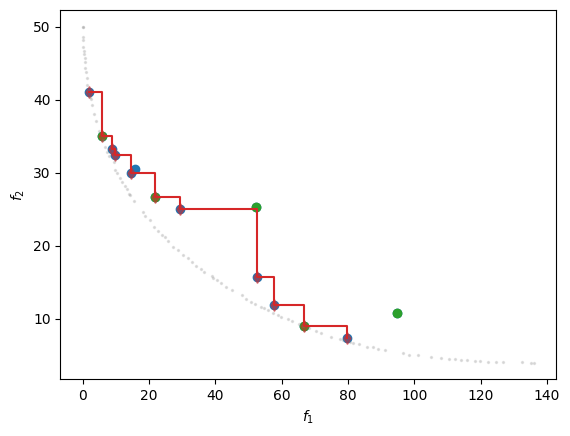

In [8]:
# ======= Optimization Pareto Front =======
# dataset = driver.dataset
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
obj = obj[rscv <= 1e-4, :]
# obj_par = get_pareto_front(obj)

pareto_front = get_pf_from_dataset(state.dataset, ctol=0.0)

# ======= Solution Pareto Front =======
pymoo_prob = PymooWrapper(problem)

algorithm = NSGA2(pop_size=100, seed=1)
res = minimize(pymoo_prob, algorithm, ("n_gen", 100), seed=1)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0], obj[:, 1])
ax.scatter(obj[:nt_init, 0], obj[:nt_init, 1], color="C2")

sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# PF obtained through optimization
ax.step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)
ax.scatter(pareto_front[:, 0], pareto_front[:, 1], marker="d", color="C3", alpha=0.5)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(res.F[:, 0], res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10)
# ax.scatter(multi_obj_ref[0], multi_obj_ref[1], 100, marker="x", color="C8", zorder=100)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

# ax.set_xlim((-0.1, 1.1))
# ax.set_ylim((-0.1, 1.1))


plt.show()

### Applying NSGA-II (pymoo) on the surrogate models

Users can use the `PymooStateWrapper` to convert a state object into a `Pymoo` `Problem` object. Below, the NSGA-II algorithm is applied on the objective and constraint models to find a predicted pareto-front.


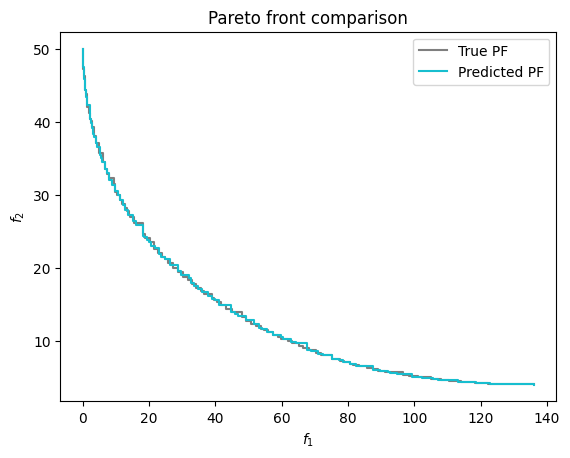

In [9]:
# Create a pymoo problem object from the SMT-Optim state object
pymoo_pred = PymooStateWrapper(state)

fig, ax = plt.subplots()

# Pareto front obtained with pymoo on the test problem directly
sorted_idx = np.argsort(res.F[:, 0])
res.F = res.F[sorted_idx, :]
ax.step(res.F[:, 0], res.F[:, 1], color="C7", where="post", label="True PF")

# Pareto front obtained with pymoo on using the surrogate models with the final DOE
res_pred = minimize(pymoo_pred, algorithm, ("n_gen", 100), seed=1)
sorted_idx = np.argsort(res_pred.F[:, 0])
res_pred.F = res_pred.F[sorted_idx, :]
ax.step(
    res_pred.F[:, 0], res_pred.F[:, 1], color="C9", where="post", label="Predicted PF"
)

ax.legend()
ax.set_title("Pareto front comparison")
ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")
plt.show()

## Constrained, multi-fidelity, and multi-objective optimization

The following example demonstrates how to find the pareto-front of a constrained multi-objective problem for which low-fidelity approximation exists.


In [10]:
problem = get_problem("DTLZ5")
problem.set_dim(4)

In [11]:
obj_config = ObjectiveConfig(
    problem.objective[0],
    type="minimize",
    surrogate=SmtAutoModel,
)

obj_config2 = ObjectiveConfig(
    problem.objective[1],
    type="minimize",
    surrogate=SmtAutoModel,
)

cstr_config = ConstraintConfig(
    problem.constraints[0],
    upper=0.0,
    surrogate=SmtAutoModel,
)

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    cstr_configs=[cstr_config],
    design_space=problem.bounds,  # problem bounds
    costs=[0.2, 1.0],
)

nt_init = 12

opt_config = DriverConfig(
    max_iter=50,
    nt_init=nt_init,
    verbose=True,
    scaling=True,
    seed=0,
)

# np.seterr(all="raise")

# driver = Driver(prob_definition, opt_config, MultiObj, strategy_kwargs={"acq_func": init_bi_obj_ei, "n_start": 1000, "sp_method": None})
driver = Driver(
    prob_definition,
    opt_config,
    MOSEGO,
    strategy_kwargs={
        "acq_func": init_bi_obj_ei,
        "n_start": 20,
        "sp_method": "SLSQP",
    },
)

In [12]:
state = driver.optimize()

          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0         16.800    2.01117e-01    0.00000e+00            nan            nan            nan
             1         17.000    2.01117e-01    0.00000e+00              1          2.216          0.967
             2         17.200    2.01117e-01    0.00000e+00              1          2.184          1.512
             3         17.400    2.01117e-01    0.00000e+00              1          2.328          1.564
             4         17.600    2.01117e-01    0.00000e+00              1          2.071          0.461
             5         17.800    2.01117e-01    0.00000e+00              1          1.664          1.178
             6         18.000    2.01117e-01    0.00000e+00              1          2.577          0.843
             7         18.200    2.01117e-01    0.00000e+00              1          2.202          1.025
             8         18.400    2.01117e-01    0.00000

/home/corde/smt-optim/src/smt_optim/core/driver.py:472: UserWarning: Infill point [1. 1. 1. 0.] already in training data. L2 = 1.6911801396061684e-12
  warnings.warn(f"Infill point {infills[lvl][idx, :]} already in training data. L2 = {np.min(l2_norms)}")


            22         27.200    2.53121e-01    1.27363e-01              2          1.795          1.497
            23         27.400    2.53121e-01    1.27363e-01              1          2.270          2.108
            24         27.600    2.53121e-01    1.27363e-01              1          1.838          1.904
            25         27.800    2.53121e-01    1.27363e-01              1          1.688          1.503
            26         28.000    2.53121e-01    1.27363e-01              1          1.976          1.116
            27         29.200    2.53134e-01    1.23740e-01              2          1.869          1.144
            28         29.400    2.53134e-01    1.23740e-01              1          1.688          1.508
            29         29.600    2.53134e-01    1.23740e-01              1          1.829          1.784
          iter         budget             HV        spacing       fidelity        gp_time       acq_time
            30         29.800    2.53134e-01    1.23740

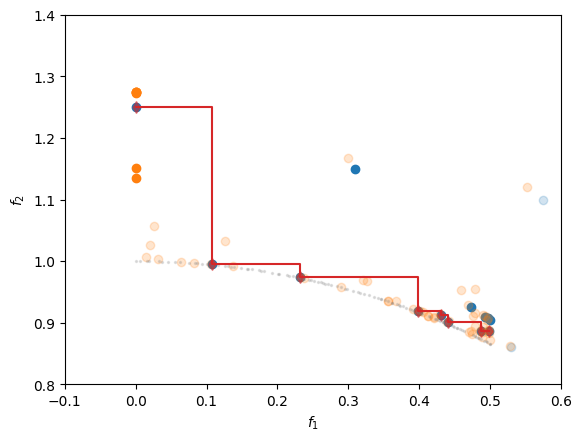

In [13]:
# ======= Optimization Pareto Front =======
# dataset = driver.dataset
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
feas_mask = rscv <= 1e-4
fid_mask = data["fidelity"] == 1
# obj = obj[rscv <= 1e-4, :]
# obj_par = get_pareto_front(obj)

pareto_front = get_pf_from_dataset(state.dataset)

# ======= Solution Pareto Front =======
pymoo_prob = PymooWrapper(problem)

algorithm = NSGA2(pop_size=100, seed=1)
res = minimize(pymoo_prob, algorithm, ("n_gen", 30), seed=1)


# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots()

ax.scatter(obj[:, 0][feas_mask & fid_mask], obj[:, 1][feas_mask & fid_mask])
ax.scatter(
    obj[:, 0][~feas_mask & fid_mask],
    obj[:, 1][~feas_mask & fid_mask],
    color="C0",
    alpha=0.2,
)
ax.scatter(
    obj[:, 0][feas_mask & ~fid_mask], obj[:, 1][feas_mask & ~fid_mask], color="C1"
)
ax.scatter(
    obj[:, 0][~feas_mask & ~fid_mask],
    obj[:, 1][~feas_mask & ~fid_mask],
    color="C1",
    alpha=0.2,
)
# ax.scatter(obj[:nt_init, 0][fid_mask], obj[:nt_init, 1][fid_mask], color="C2")

sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# PF obtained through optimization
ax.step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)
ax.scatter(pareto_front[:, 0], pareto_front[:, 1], marker="d", color="C3", alpha=0.5)

# Solution PF
# ax.scatter(F1, F2, 2, color="C7", alpha=0.2, zorder=10)
ax.scatter(res.F[:, 0], res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.set_xlim((-0.1, 0.6))
ax.set_ylim((0.8, 1.4))

plt.show()

## Optimization with BiEGO and Adaptive Nadir Points

BiEGO is a multi-objective strategy that leverages adaptive nadir (reference) points to guide the optimization process. Below, we solve the ZDT1 problem using BiEGO and visualize how these reference points adapt over the iterations.

In [ ]:
from smt_optim.acquisition_strategies.biego import BiEGO

nt_init = 5

opt_config_comp = DriverConfig(max_iter=15, nt_init=nt_init, seed=42)

driver_comp = Driver(
    problem=prob_definition, 
    config=opt_config_comp, 
    strategy=BiEGO,
    strategy_kwargs={"min_max_calls": 2, "n_multi_start": 50},
)

state_comp = driver_comp.optimize()

# Visualizing the trajectory with an interactive animation
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from smt_optim.utils.multi_obj import get_pareto_mask
import numpy as np

r_history = driver_comp.strategy.r_history
y_all = state_comp.dataset.export_as_dict()["obj"]
y_init = y_all[:nt_init]
y_infills = y_all[nt_init:]

fig, ax = plt.subplots(figsize=(6, 4))
x1 = np.linspace(0, 1, 100)
ax.plot(x1, 1 - np.sqrt(x1), "k-", label="Ref PF", linewidth=2)
scatter_pareto, = ax.plot([], [], "o", color="darkorange", label="Pareto Optimal", alpha=0.9)
scatter_dom, = ax.plot([], [], "bo", label="Dominated", alpha=0.4)
scatter_new, = ax.plot([], [], "r*", markersize=12, label="New Infill")
nadir_marker, = ax.plot([], [], "mX", markersize=10, label="Adaptive Nadir (r)")
nadir_hline = ax.axhline(0, color="m", linestyle="--", alpha=0.5)
nadir_vline = ax.axvline(0, color="m", linestyle="--", alpha=0.5)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper right")

def init():
    scatter_pareto.set_data([], [])
    scatter_dom.set_data([], [])
    scatter_new.set_data([], [])
    nadir_marker.set_data([], [])
    nadir_hline.set_visible(False)
    nadir_vline.set_visible(False)
    return scatter_pareto, scatter_dom, scatter_new, nadir_marker, nadir_hline, nadir_vline

def update(frame):
    i = frame + 4
    if i >= len(y_infills): return scatter_pareto, scatter_dom, scatter_new, nadir_marker, nadir_hline, nadir_vline
    all_past_pts = np.vstack((y_init, y_infills[:i]))
    if len(all_past_pts) > 0:
        p_mask = get_pareto_mask(all_past_pts)
        scatter_pareto.set_data(all_past_pts[p_mask][:, 0], all_past_pts[p_mask][:, 1])
        scatter_dom.set_data(all_past_pts[~p_mask][:, 0], all_past_pts[~p_mask][:, 1])
    scatter_new.set_data([y_infills[i, 0]], [y_infills[i, 1]])
    if i < len(r_history) and r_history[i] is not None:
        r_unscaled = r_history[i]
        nadir_marker.set_data([r_unscaled[0]], [r_unscaled[1]])
        nadir_hline.set_ydata([r_unscaled[1], r_unscaled[1]])
        nadir_vline.set_xdata([r_unscaled[0], r_unscaled[0]])
        nadir_hline.set_visible(True)
        nadir_vline.set_visible(True)
    ax.set_title(f"BiEGO Composite: Infill {i+1}")
    ax.relim()
    ax.autoscale_view()
    return scatter_pareto, scatter_dom, scatter_new, nadir_marker, nadir_hline, nadir_vline

n_frames = max(0, len(y_infills) - 4)
ani = FuncAnimation(fig, update, frames=n_frames, init_func=init, blit=False, repeat=False)
plt.close(fig)
HTML(ani.to_jshtml())



## Comparison: Composite vs Naive BiEGO

We can toggle the `naive` flag in BiEGO to compare Antoine's composite function adaptation (which samples the joint GP distributions using Monte-Carlo) against the naive method (which strictly fits a single scalar surrogate on the composite formulation).

In [ ]:
opt_config_naive = DriverConfig(max_iter=15, nt_init=nt_init, seed=42)

driver_naive = Driver(
    problem=prob_definition, 
    config=opt_config_naive, 
    strategy=BiEGO,
    strategy_kwargs={"min_max_calls": 2, "n_multi_start": 50, "naive": True},
)

state_naive = driver_naive.optimize()

r_history_n = driver_naive.strategy.r_history
y_all_n = state_naive.dataset.export_as_dict()["obj"]
y_init_n = y_all_n[:nt_init]
y_infills_n = y_all_n[nt_init:]

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(x1, 1 - np.sqrt(x1), "k-", label="Ref PF", linewidth=2)
scatter_pareto_n, = ax2.plot([], [], "o", color="darkorange", label="Pareto Optimal", alpha=0.9)
scatter_dom_n, = ax2.plot([], [], "bo", label="Dominated", alpha=0.4)
scatter_new_n, = ax2.plot([], [], "r*", markersize=12, label="New Infill")
nadir_marker_n, = ax2.plot([], [], "mX", markersize=10, label="Adaptive Nadir (r)")
nadir_hline_n = ax2.axhline(0, color="m", linestyle="--", alpha=0.5)
nadir_vline_n = ax2.axvline(0, color="m", linestyle="--", alpha=0.5)
ax2.set_xlabel("$f_1$")
ax2.set_ylabel("$f_2$")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(loc="upper right")

def update_naive(frame):
    i = frame + 4
    if i >= len(y_infills_n): return scatter_pareto_n, scatter_dom_n, scatter_new_n, nadir_marker_n, nadir_hline_n, nadir_vline_n
    all_past_pts = np.vstack((y_init_n, y_infills_n[:i]))
    if len(all_past_pts) > 0:
        p_mask = get_pareto_mask(all_past_pts)
        scatter_pareto_n.set_data(all_past_pts[p_mask][:, 0], all_past_pts[p_mask][:, 1])
        scatter_dom_n.set_data(all_past_pts[~p_mask][:, 0], all_past_pts[~p_mask][:, 1])
    scatter_new_n.set_data([y_infills_n[i, 0]], [y_infills_n[i, 1]])
    if i < len(r_history_n) and r_history_n[i] is not None:
        r_unscaled = r_history_n[i]
        nadir_marker_n.set_data([r_unscaled[0]], [r_unscaled[1]])
        nadir_hline_n.set_ydata([r_unscaled[1], r_unscaled[1]])
        nadir_vline_n.set_xdata([r_unscaled[0], r_unscaled[0]])
        nadir_hline_n.set_visible(True)
        nadir_vline_n.set_visible(True)
    ax2.set_title(f"BiEGO Naive: Infill {i+1}")
    ax2.relim()
    ax2.autoscale_view()
    return scatter_pareto_n, scatter_dom_n, scatter_new_n, nadir_marker_n, nadir_hline_n, nadir_vline_n

n_frames_n = max(0, len(y_infills_n) - 4)
ani2 = FuncAnimation(fig2, update_naive, frames=n_frames_n, blit=False, repeat=False)
plt.close(fig2)
HTML(ani2.to_jshtml())



## Comparison: MOSEGO (MPI)

Finally, let's look at **MOSEGO** which uses the **Minimum Probability of Improvement (MPI)** acquisition function. Unlike BiEGO, it does not rely on geometric gap calculation (Adaptive Nadir). Instead, it evaluates the global probability of dominating the front at any point, providing a much more globally uniform sampling across the entire Pareto front.


In [ ]:
from smt_optim.acquisition_strategies.mosego import MOSEGO

opt_config_mosego = DriverConfig(max_iter=15, nt_init=nt_init, seed=42)

driver_mosego = Driver(
    problem=prob_definition, 
    config=opt_config_mosego, 
    strategy=MOSEGO
)

state_mosego = driver_mosego.optimize()

y_all_m = state_mosego.dataset.export_as_dict()["obj"]
y_init_m = y_all_m[:nt_init]
y_infills_m = y_all_m[nt_init:]

fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(x1, 1 - np.sqrt(x1), "k-", label="Ref PF", linewidth=2)
scatter_pareto_m, = ax3.plot([], [], "o", color="darkorange", label="Pareto Optimal", alpha=0.9)
scatter_dom_m, = ax3.plot([], [], "bo", label="Dominated", alpha=0.4)
scatter_new_m, = ax3.plot([], [], "r*", markersize=12, label="New Infill")
ax3.set_xlabel("$f_1$")
ax3.set_ylabel("$f_2$")
ax3.grid(True, linestyle="--", alpha=0.6)
ax3.legend(loc="upper right")

def update_mosego(frame):
    i = frame
    if i >= len(y_infills_m): return scatter_pareto_m, scatter_dom_m, scatter_new_m
    all_past_pts = np.vstack((y_init_m, y_infills_m[:i]))
    if len(all_past_pts) > 0:
        p_mask = get_pareto_mask(all_past_pts)
        scatter_pareto_m.set_data(all_past_pts[p_mask][:, 0], all_past_pts[p_mask][:, 1])
        scatter_dom_m.set_data(all_past_pts[~p_mask][:, 0], all_past_pts[~p_mask][:, 1])
    scatter_new_m.set_data([y_infills_m[i, 0]], [y_infills_m[i, 1]])
    ax3.set_title(f"MOSEGO (MPI): Infill {i+1}")
    ax3.relim()
    ax3.autoscale_view()
    return scatter_pareto_m, scatter_dom_m, scatter_new_m

n_frames_m = len(y_infills_m)
ani3 = FuncAnimation(fig3, update_mosego, frames=n_frames_m, blit=False, repeat=False)
plt.close(fig3)
HTML(ani3.to_jshtml())



from smt_optim.utils.multi_obj import hypervolume_2d

# Reference point for computing hypervolume
ref_point = np.array([2.0, 2.0])

hv_comp = []
hv_naive = []
hv_mosego = []

obj_comp = state_comp.dataset.export_as_dict()["obj"]
obj_naive = state_naive.dataset.export_as_dict()["obj"]
obj_mosego = state_mosego.dataset.export_as_dict()["obj"]

total_evals = len(obj_comp)
iterations = list(range(1, total_evals - nt_init + 1))

for i in range(nt_init, total_evals):
    # Comp
    mask_c = get_pareto_mask(obj_comp[:i])
    hv_comp.append(hypervolume_2d(obj_comp[:i][mask_c], ref_point))
    # Naive
    mask_n = get_pareto_mask(obj_naive[:i])
    hv_naive.append(hypervolume_2d(obj_naive[:i][mask_n], ref_point))
    # Mosego
    mask_m = get_pareto_mask(obj_mosego[:i])
    if len(obj_mosego[:i][mask_m]) > 0:
        hv_mosego.append(hypervolume_2d(obj_mosego[:i][mask_m], ref_point))
    else:
        hv_mosego.append(0.0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(iterations, hv_comp, 'b-o', label='BiEGO (Composite)', alpha=0.8)
ax.plot(iterations, hv_naive, 'r-s', label='BiEGO (Naive)', alpha=0.8)
ax.plot(iterations[:len(hv_mosego)], hv_mosego, 'g-^', label='MOSEGO (MPI)', alpha=0.8)
ax.set_xlabel('Infill Iterations')
ax.set_ylabel('Hypervolume Indicator')
ax.set_title('Hypervolume Convergence on ZDT1')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()



## Advanced Post-Processing and Data Profiles

The SMT-Optim framework includes advanced post-processing tools inspired by the work of Oihan Cordelier and Antoine Maugras. These tools allow you to plot **Data Profiles**, **Performance Profiles**, **Convergence Profiles**, and **Accuracy Profiles** over several analytical instances.

To utilize these tools, you can import them from `smt_optim.utils.profiles`. Here is a quick example of how you might aggregate multiple runs across different frameworks (like `MOSEGO` and `BiEGO`) to generate these profiles:

In [ ]:
from smt_optim.utils.profiles import profile, convergence_profile

# Note: The profiling functions generally expect dictionary data structures 
# aggregating multiple instances over several algorithms. 
# 
# data = {
#     'MOSEGO': { 'ZDT1': np.array([...]), 'ZDT2': np.array([...]) },
#     'BiEGO':  { 'ZDT1': np.array([...]), 'ZDT2': np.array([...]) }
# }
#
# perf_profile = profile(data, tau=0.1, type='perf')
# data_profile = profile(data, tau=0.1, type='data', dim={'ZDT1': 2, 'ZDT2': 2})
#
# These profiles can then be plotted using matplotlib to visually compare 
# the robustness and efficiency of the Bayesian optimization frameworks.